In [53]:
#Step 1: Load and prepare data
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib.inline

UsageError: Line magic function `%matplotlib.inline` not found.


In [ ]:
df = pd.read_csv("rhythm_synthetic_data.csv")

In [85]:
df.head()

,cycle_day,sleep_quality,energy,mood,bloating,cravings,phase
0,1,2,3,3,2,4,Menstrual
1,4,0,1,5,2,2,Menstrual
2,1,0,2,4,2,4,Menstrual
3,8,0,3,5,2,1,Follicular
4,1,2,3,4,3,2,Menstrual


In [70]:
df = df.drop(columns=['user_id', 'cycle_length'])

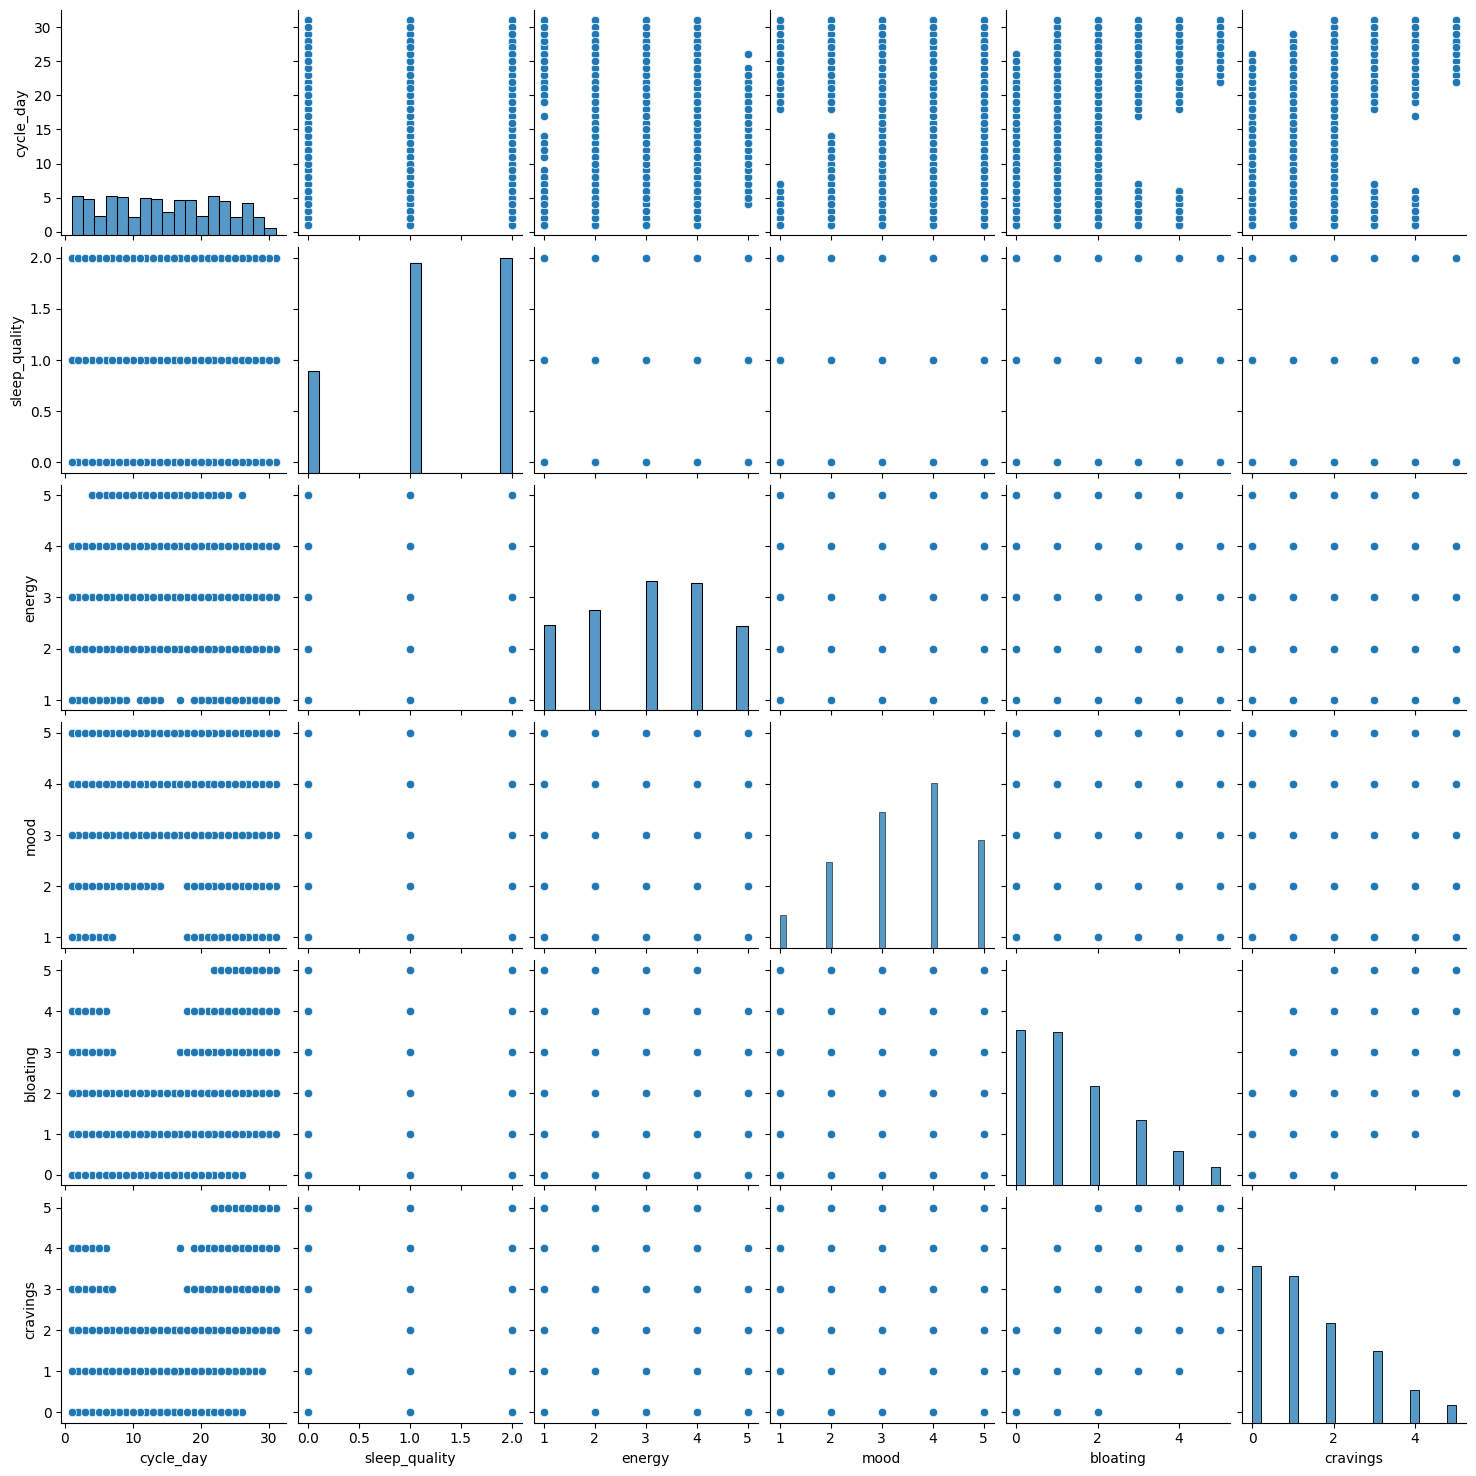

In [71]:
#visualization
import seaborn as sns
sns.pairplot(df)

In [87]:
feature_cols = ['cycle_day', 'sleep_quality', 'energy', 'mood', 'bloating', 'cravings']
X = df[feature_cols]
y = df['phase']

In [73]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Initialize and fit-transform LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Encoded Y: {y_encoded}")

Encoded Y: [3 3 3 ... 1 2 4]


In [74]:
#Step 2: Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
X_train.size

24000

In [76]:
X_test.size

6000

In [77]:
#Step 3: Train
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [78]:
#Evaluate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

In [79]:
#Get predictions on the test set
y_pred = model.predict(X_test)

In [80]:
# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")

Overall Accuracy: 93.20%


In [81]:
# Full report — precision, recall, F1 per phase
print("Classification Report: ")
print(classification_report(y_test,y_pred,target_names=le.classes_))

Classification Report: 
              precision    recall  f1-score   support

Early Luteal       0.90      0.92      0.91       172
  Follicular       0.95      0.93      0.94       301
 Late Luteal       0.94      0.91      0.92       169
   Menstrual       0.98      0.98      0.98       180
   Ovulation       0.88      0.93      0.90       178

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



In [82]:
# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

# Print it with phase names as labels so it's readable
phases = le.classes_
header = f"{'':15}" + "".join(f"{p:15}" for p in phases)
print(header)
for i, row in enumerate(cm):
    row_str = f"{phases[i]:15}" + "".join(f"{val:<15}" for val in row)
    print(row_str)

Confusion Matrix:
               Early Luteal   Follicular     Late Luteal    Menstrual      Ovulation      
Early Luteal   158            0              10             0              4              
Follicular     0              279            0              4              18             
Late Luteal    15             0              154            0              0              
Menstrual      0              4              0              176            0              
Ovulation      2              11             0              0              165            


In [83]:
import joblib
joblib.dump(model, "phase_classifier.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [84]:
# ── Feature Importance ────────────────────────────────────
feature_names = X.columns.tolist()
importances = model.feature_importances_

sorted_features = sorted(
    zip(feature_names, importances),
    key=lambda x: x[1],
    reverse=True
)

print("\nFeature Importance:")
for feature, importance in sorted_features:
    bar = "█" * int(importance * 50)
    print(f"  {feature:20} {importance:.4f}  {bar}")


Feature Importance:
  cycle_day            0.5929  █████████████████████████████
  cravings             0.1116  █████
  bloating             0.1115  █████
  energy               0.0980  ████
  mood                 0.0625  ███
  sleep_quality        0.0234  █


In [96]:
#TEST

import joblib
import pandas as pd

model = joblib.load("phase_classifier.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# Simulate a single user input
test_input = pd.DataFrame([{
    #cycle_day	sleep_quality	energy	mood	bloating	cravings
    "cycle_day": 26,
    "sleep_quality": 0,
    "energy": 2,
    "mood": 2,
    "bloating": 1,
    "cravings": 2    
}])

prediction = model.predict(test_input)
print("Predicted phase:", prediction[0])


Predicted phase: Late Luteal
